## Spin Coherence Time by Mapping Method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import ScalarFormatter

## Data Structure and Path Configuration

This section defines the data acquisition environment and the multi-particle probe logic used to analyze the spin response.

### 1. Root Directory and Lattice List
*   **Root Path**: `root_path` specifies the local repository containing the COSY-INFINITY simulation results.
*   **Lattice Structures**: Identifiers for the analyzed magnet configurations:
    *   `magnetic_2p` / `magnetic_sextupoles` / `magnetic_mod`: Standard magnetic lattices.
    *   `electrostatic`: Purely electric field configuration.
    *   `Nuclotron_8` / `Nuclotron_16`: Quasi-Frosen Spin lattices.

### 2. Input Files and Multi-Particle Schema
The analysis utilizes three primary data files per lattice configuration. The "Particle 0" and "Particle 1" datasets actually represent a set of **6 distinct particle probes** used to sample the phase space:

*   **`integrals` (`cols_int`)**: Contains sextupole current families (`SG`) and lattice integrals observables: transverse chromaticities ($\xi_x, \xi_y$) and the longitudinal component ($\eta_1$).
*   **`particle_spin_tune` (`cols_s0`)**: Spin response for three probes with **nominal** offsets. Each axis ($x, y, z$) is sampled by a dedicated particle with a small initial deviation in that specific plane.
*   **`particle_spin_tune_1` (`cols_s1`)**: Spin response for three probes with **increased** offsets. Similar to the first set, but with larger initial amplitudes to analyze non-linearities.

### 3. Simulation Ranges and Plane Decoupling
To isolate the Jacobian-driven sensitivity, we scan one parameter while keeping the others constrained to their natural baseline:

*   **Scan Ranges**: 
    *   Horizontal ($\xi_x$): $[-10, 10]$ 
    *   Vertical ($\xi_y$): $[-10, 10]$ 
    *   Longitudinal ($\eta_1$): $[-1, 1]$
*   **Decoupling Constraints**:
    *   **$x$-plane analysis**: Calculated at $\xi_y = 0$ and $\eta_1 = 0$.
    *   **$y$-plane analysis**: Calculated at $\xi_x = 0$ and $\eta_1 = 0$.
    *   **$z$-plane analysis**: Calculated at $\xi_x = 0$ and $\xi_y = 0$.

In [2]:
plt.rcParams.update({'font.size': 10, 'axes.grid': True})

root_path = 'C:/GIT_REPOS/SCT/COSY/src/dat/'
lattices = ['magnetic_2p','magnetic_sextupoles', 'magnetic_mod', 'electrostatic','Nuclotron_8', 'Nuclotron_16', 'Nuclotron_8_mag'] 

# --- Plotting Configuration ---
steps = 100
ranges = [np.linspace(-10, 10, steps), np.linspace(-10, 10, steps), np.linspace(-1, 1, steps)]
labels = [r'$\xi_x$', r'$\xi_y$', r'$\eta_1$']
colors = ['red', 'blue', 'green']
plane_names = ['x', 'y', 'z']
# Specific constraints for cross-plane decoupling
constraints = [r'$\xi_y=0, \eta_1=0$', r'$\xi_x=0, \eta_1=0$', r'$\xi_x=0, \xi_y=0$']


cols_int = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'chrom_x', 'chrom_y', 'MU_ref', 'quad_Kx', 'quad_Ky', 'quad_Kz', 'alpha_0', 'alpha_1', 'eta_1']
cols_s0  = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'spin_ref', 'spin_x', 'spin_y', 'spin_z']
cols_s1  = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'spin_ref_1', 'spin_x_1', 'spin_y_1', 'spin_z_1']

## Data Loading and Preprocessing

The `get_data` function automates the acquisition and standardization of simulation results, merging the control parameters with the corresponding multi-particle spin responses.

### 1. File Acquisition and Cleaning
The function processes three primary datasets (`integrals`, `particle_spin_tune`, and `particle_spin_tune_1`). During import, the following numerical cleaning is performed to ensure compatibility with Python's scientific stack:
*   **Exponent Conversion**: Replaces Fortran double-precision delimiters (`D`) with standard scientific notation (`E`).
*   **Type Casting**: Converts raw string output into numeric floats.
*   **Integrity Check**: Removes incomplete rows (NaNs) to prevent errors during matrix inversion.

### 2. Synchronization of Probes
To map the spin response of the 6 distinct particle probes to the specific machine state, the datasets are merged into a master DataFrame. 
*   **Mapping Key**: Synchronization is performed using the unique **sextupole current families** (`SGx1, SGx2, SGy1, SGy2`) as keys. 
*   **Result**: Every row in the final DataFrame provides a complete snapshot of the machine: the control currents, the achieved chromaticities, and the resulting spin tune deviations for all sampled orbital offsets.


In [3]:
def get_data(lattice, mode):
    """
    Loads and cleans experimental data from three separate .dat files.
    
    Parameters:
    lattice (str): Folder name for the specific magnet structure (e.g., 'Nuclotron_8').
    mode (str): Field configuration mode ('FR0' for ideal, 'FR3' for fringe fields).
    
    Returns:
    pd.DataFrame: A single merged DataFrame containing integrals and spin tunes for 2 particles.
    """
    base = os.path.join(root_path, lattice)
    
    # Define file paths for integrals, particle 0 spin tune, and particle 1 spin tune
    f = {
        'int': f'{base}/integrals_{mode}.dat', 
        's0':  f'{base}/particle_spin_tune_{mode}.dat', 
        's1':  f'{base}/particle_spin_tune_1_{mode}.dat'
    }
    
    # Check if all required files exist before proceeding
    if not all(os.path.exists(p) for p in f.values()): 
        print(f"Warning: Missing files in {base} for mode {mode}")
        return None

    dfs = {}
    for k, p in f.items():
        # Assign correct column headers based on file type
        c = cols_int if k == 'int' else (cols_s0 if k == 's0' else cols_s1)
        
        # Load the space-separated values file
        tmp = pd.read_csv(p, sep=r'\s+', names=c, engine='python')
        
        # DATA CLEANING:
        # 1. Convert Fortran double precision exponents ('D') to Python standard ('E')
        # 2. Convert string representations to numeric floats
        # 3. Drop any rows containing NaN values to ensure matrix stability
        for col in tmp.columns: 
            tmp[col] = pd.to_numeric(tmp[col].astype(str).str.replace('D', 'E'), errors='coerce')
        dfs[k] = tmp.dropna()

    # MERGING PROCESS:
    # We use the sextupole currents (SGx1, SGx2, SGy1, SGy2) as unique keys 
    # to align integrals and spin tune data for both particles.
    m = pd.merge(dfs['int'], dfs['s0'], on=['SGx1', 'SGx2', 'SGy1', 'SGy2'])
    return pd.merge(m, dfs['s1'], on=['SGx1', 'SGx2', 'SGy1', 'SGy2'])

## Linear Response Model Mathematics

The analysis evaluates the impact of sextupole field corrections on machine observables. We assume a linear relationship where the observed state is the sum of the **natural baseline** (the bare lattice) and the **dynamic response** to control currents.

### Fundamental Equations
The machine state for any set of sextupole currents $\vec{I} = [I_1, I_2, I_3]^T$ (corresponding to the $SG_{x1}, SG_{x2}, SG_{y1}$ magnet families) is modeled as:

$$\vec{\xi} = \mathbf{R}_{int} \cdot \vec{I} + \vec{\xi}_{nat}$$
$$\Delta\vec{\nu}_s = \mathbf{R}_{spin} \cdot \vec{I} + \Delta\vec{\nu}_{s, nat}$$

Where:
*   **$\vec{\xi}$**: Chromaticity/Integrals vector $[\xi_x, \xi_y, \eta_1]^T$.
*   **$\Delta\vec{\nu}_s$**: Spin tune deviation vector $[\Delta\nu_x, \Delta\nu_y, \Delta\nu_z]^T$.
*   **$\mathbf{R}_{int}, \mathbf{R}_{spin}$**: Jacobian matrices ($3 \times 3$) representing the sensitivity (slopes) of the system.
*   **$\vec{\xi}_{nat}$**: **Natural Chromaticity** vector representing the baseline state when all sextupoles are off ($\vec{I}=0$).
*   **$\Delta\vec{\nu}_{s, nat}$**: **Natural Spin Tune** vector representing the baseline precession deviation when all sextupoles are off ($\vec{I}=0$).

---

### Numerical Methodology (OLS Regression)
To extract the Jacobians ($\mathbf{R}$) and natural vectors ($\vec{nat}$), we use **Ordinary Least Squares (OLS)** regression.

**Design Matrix ($\mathbf{X}$):**
We construct a matrix containing the input currents from $n$ observations and a column of ones to calculate the natural offsets:
$$\mathbf{X} = \begin{pmatrix} 
I_{1,1} & I_{2,1} & I_{3,1} & 1 \\
\vdots & \vdots & \vdots & \vdots \\
I_{1,n} & I_{2,n} & I_{3,n} & 1 
\end{pmatrix}$$

**Solving for Coefficients ($\beta$):**
Using `np.linalg.lstsq`, we find the coefficient matrix $\beta$ that minimizes the residual sum of squares between the inputs and the measured data $\mathbf{Y}$:
$$\min_{\beta} \|\mathbf{Y} - \mathbf{X}\beta\|^2$$

The matrix $\beta$ resulting from the OLS regression contains all the model parameters in a single $4 \times 3$ block:

$$\beta = \begin{pmatrix} 
R_{11} & R_{12} & R_{13} \\
R_{21} & R_{22} & R_{23} \\
R_{31} & R_{32} & R_{33} \\
\hline
nat_x & nat_y & nat_z 
\end{pmatrix} 
\begin{matrix} 
\leftarrow \text{Sensitivity to } I_1 \\
\leftarrow \text{Sensitivity to } I_2 \\
\leftarrow \text{Sensitivity to } I_3 \\
\leftarrow \textbf{Natural State } (I=0)
\end{matrix}$$

*   **Top 3 rows**: Form the response matrix $\mathbf{R}$ (Jacobian).
*   **Bottom row**: Defines the natural baseline vector ($\vec{\xi}_{nat}$ or $\Delta\vec{\nu}_{s, nat}$).


In [4]:
def get_dual_model(df, suffix=''):
    """
    Constructs the linear response model for a specific particle.
    
    R_spin:   3x3 Matrix representing spin tune response to sextupole currents.
    spin_nat: 1x3 Vector representing natural spin tune (intercept) at zero current.
    R_int:    3x3 Matrix representing chromaticity/integral response to currents.
    int_nat:  1x3 Vector representing natural chromaticity (intercept) at zero current.
    """
    # Design Matrix: Sextupole currents (SGx1, SGx2, SGy1) and a constant term (ones)
    X_design = np.column_stack([df['SGx1'], df['SGx2'], df['SGy1'], np.ones(len(df))])
    
    # Spin Response Model
    y_spin = df[[f'spin_x{suffix}', f'spin_y{suffix}', f'spin_z{suffix}']].values
    beta_s, _, _, _ = np.linalg.lstsq(X_design, y_spin, rcond=None)
    
    # Chromaticity/Integrals Response Model
    y_chrom = df[['chrom_x', 'chrom_y', 'eta_1']].values
    beta_c, _, _, _ = np.linalg.lstsq(X_design, y_chrom, rcond=None)
    
    return {
        'R_spin': beta_s[:3, :].T, 
        'spin_nat': beta_s[3, :], 
        'R_int': beta_c[:3, :].T, 
        'int_nat': beta_c[3, :]
    }

## Independent Control and Response Simulation

This section simulates the physical tuning of the accelerator and the resulting spin response by treating each field configuration as an independent physical system.

### 1. Independent Current Recalibration (Inverse Problem)
To achieve a specific chromaticity state, we calculate the required sextupole currents $\vec{I} = [I_1, I_2, I_3]^T$ independently for each machine configuration. This accounts for the fact that **With Fringe** and **No Fringe** models have different optics and require different magnetic strengths to reach the same $\vec{\xi}_{target}$:

$$\vec{I}_{mode} = \mathbf{R}_{int, mode}^{-1} \cdot (\vec{\xi}_{target} - \vec{\xi}_{nat, mode})$$

*   **$\mathbf{R}_{int, mode}$**: The Chromaticity Jacobian specific to the selected field mode (Fringe or No Fringe).
*   **Decoupling Strategy**: The $\vec{\xi}_{target}$ is defined to isolate one plane at a time (e.g., $[\xi_{x, target}, 0, 0]^T$). This forces the system to find currents that compensate for the natural chromaticity in all three planes simultaneously.

### 2. Multi-Particle Spin Response (Forward Problem)
Once the currents $\vec{I}_{mode}$ are determined, they are applied to the individual spin models for both the reference ($P0$) and off-orbit ($P1$) particles to calculate the spin tune deviation:

$$\Delta\vec{\nu}_{s, particle} = \mathbf{R}_{spin, particle} \cdot \vec{I}_{mode} + \Delta\vec{\nu}_{s, nat, particle}$$

### 3. Spin-Chromaticity Transfer Function
By substituting the inverse control law into the forward response model, we define the **Sensitivity Operator ($\mathbf{S}$)** that directly links chromaticity to spin tune deviation:

$$\Delta\vec{\nu}_{s, particle} = \underbrace{(\mathbf{R}_{spin, particle} \cdot \mathbf{R}_{int, mode}^{-1})}_{\mathbf{S}} \cdot (\vec{\xi}_{target} - \vec{\xi}_{nat, mode}) + \Delta\vec{\nu}_{s, nat, particle}$$

This operator $\mathbf{S}$ represents the "transfer function" of the system, quantifying the spin tune shift per unit of corrected chromaticity. The divergence observed in the final plots is a result of:
*   **Optic Distortion**: Changes in the Sensitivity Operator $\mathbf{S}$ caused by realistic fringe field distributions.
*   **Amplitude Dependency**: Variations in $\mathbf{S}$ between particles $P0$ and $P1$ due to their different orbital offsets.

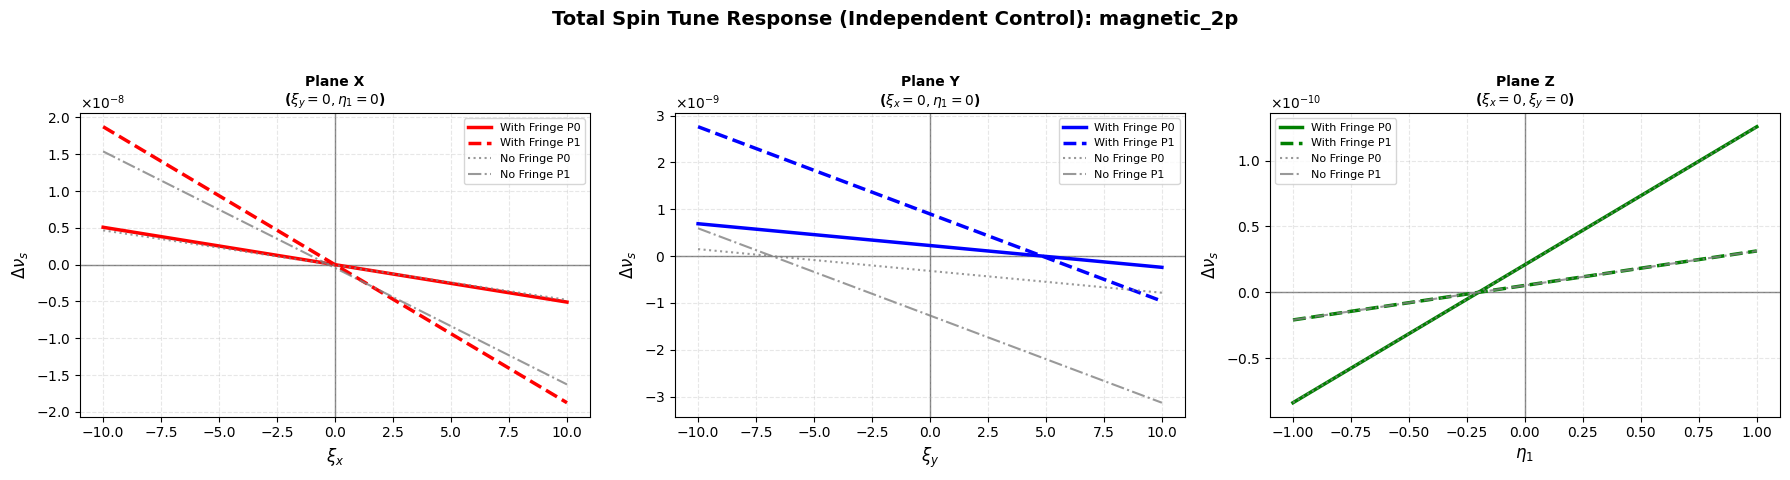

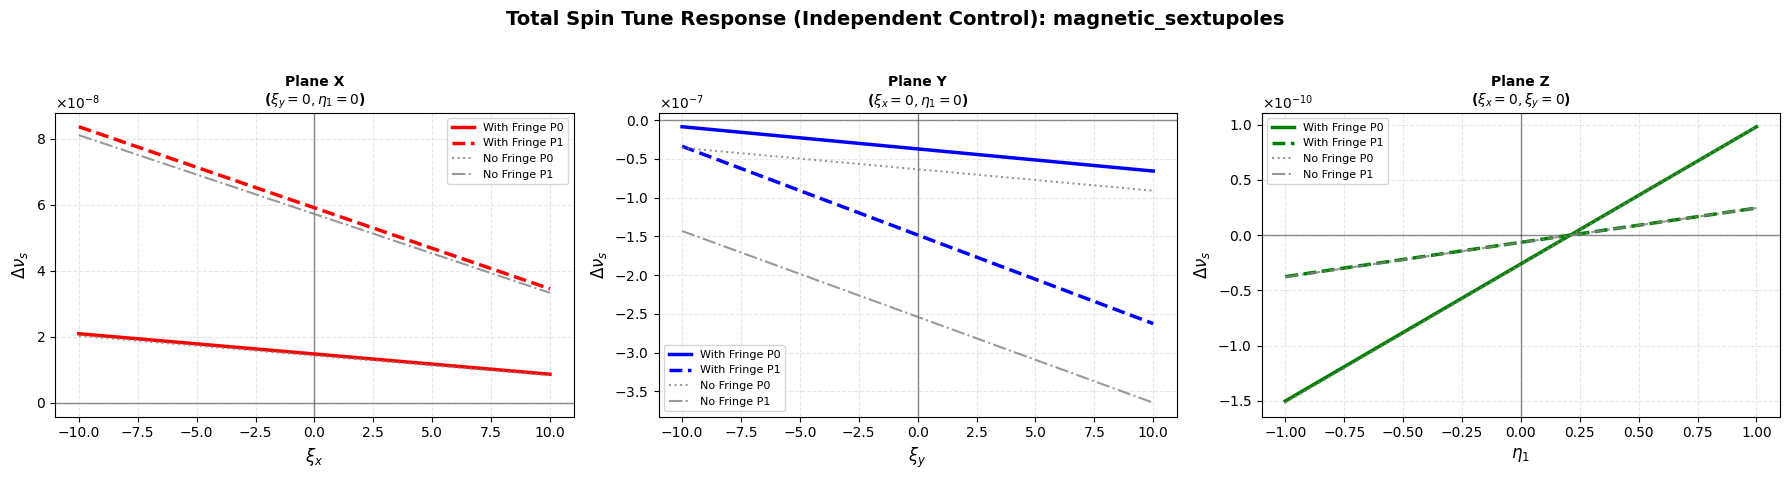

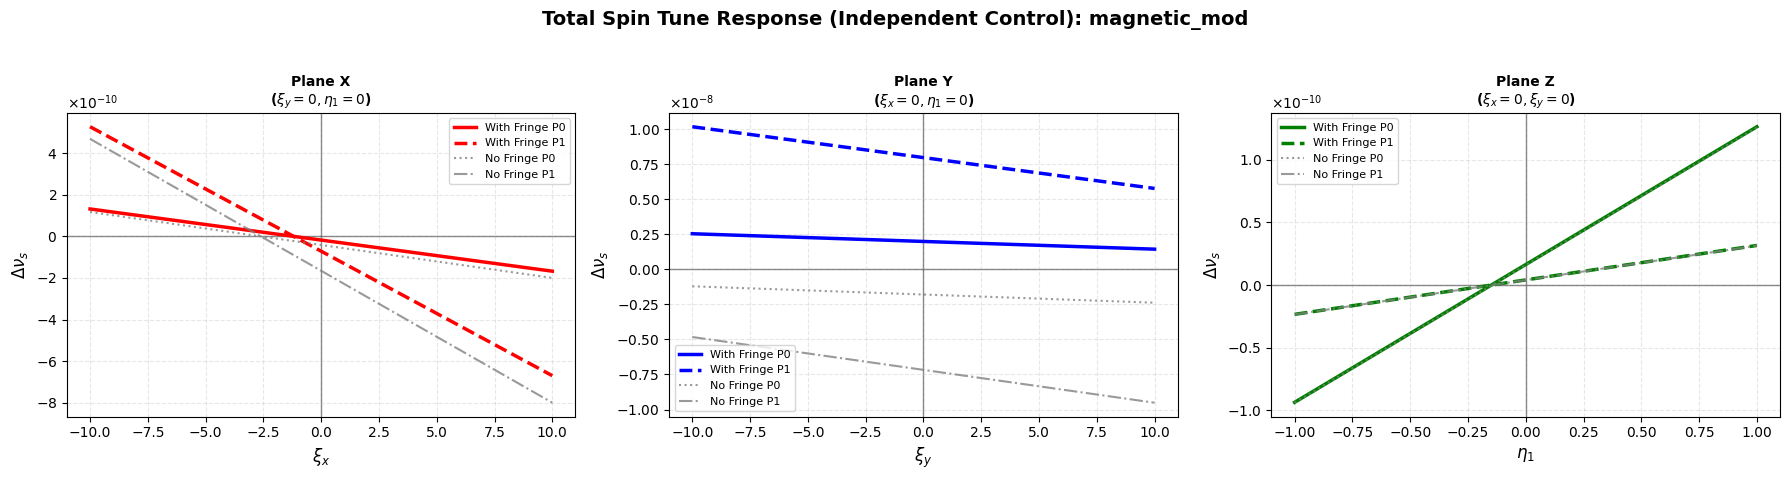

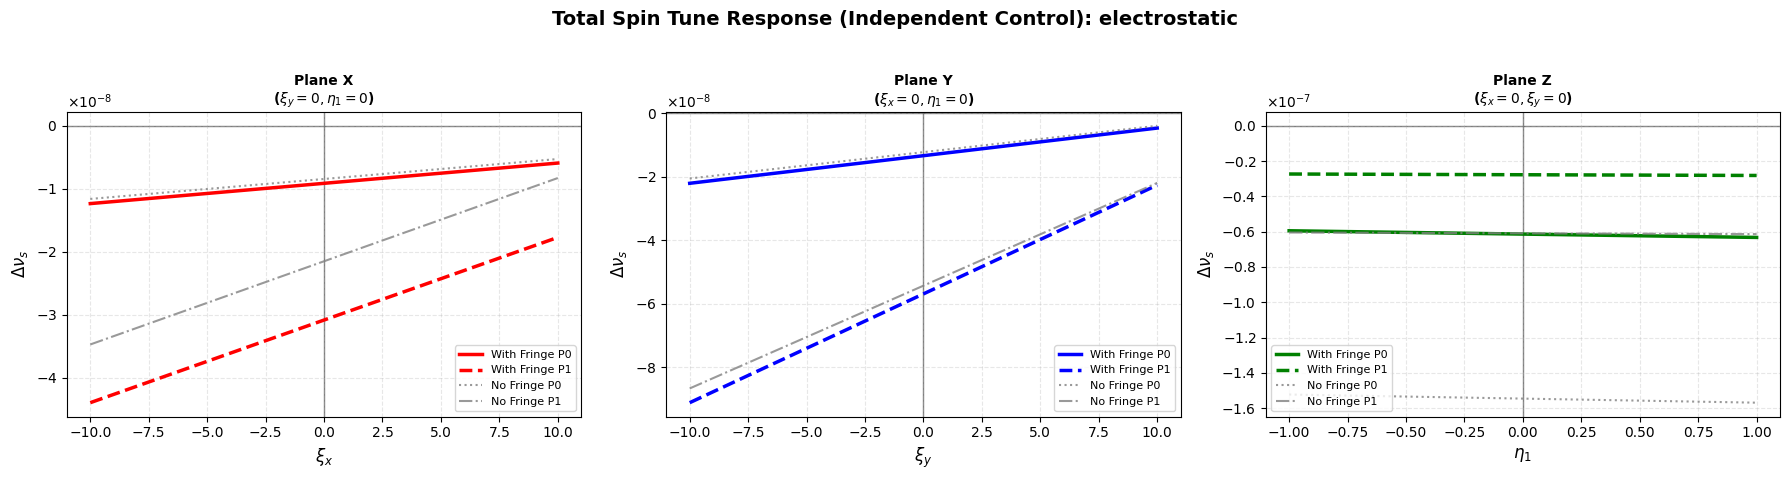

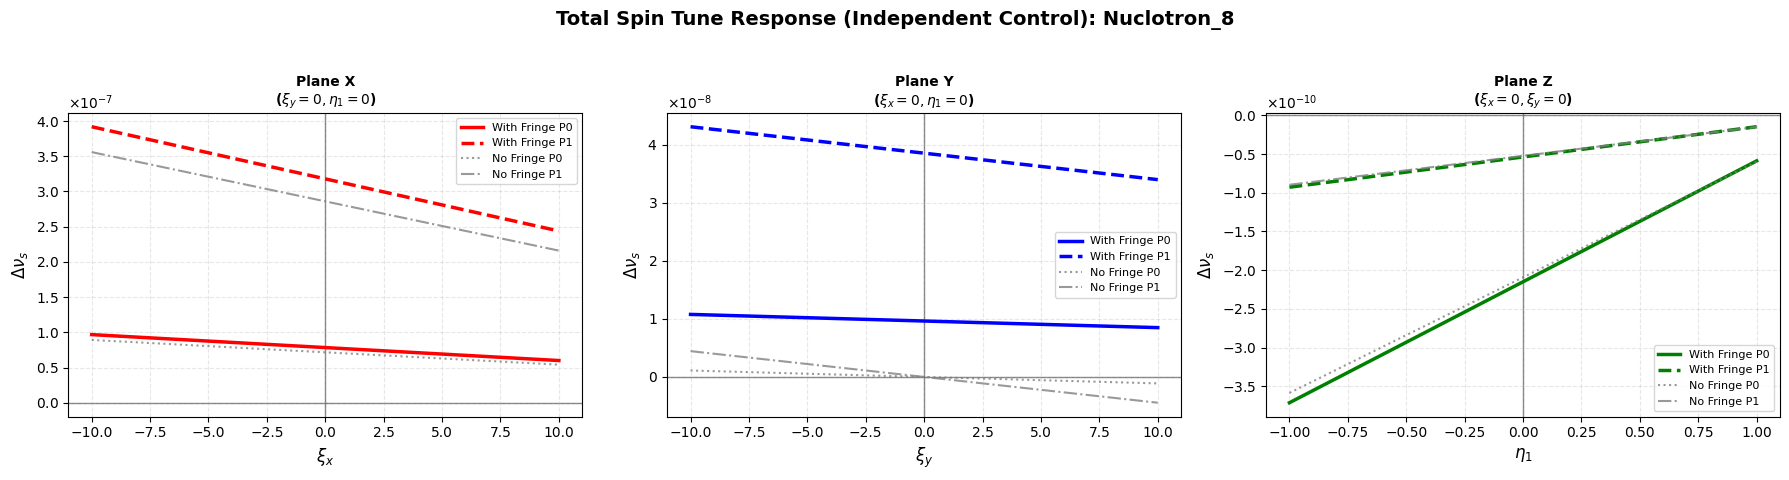

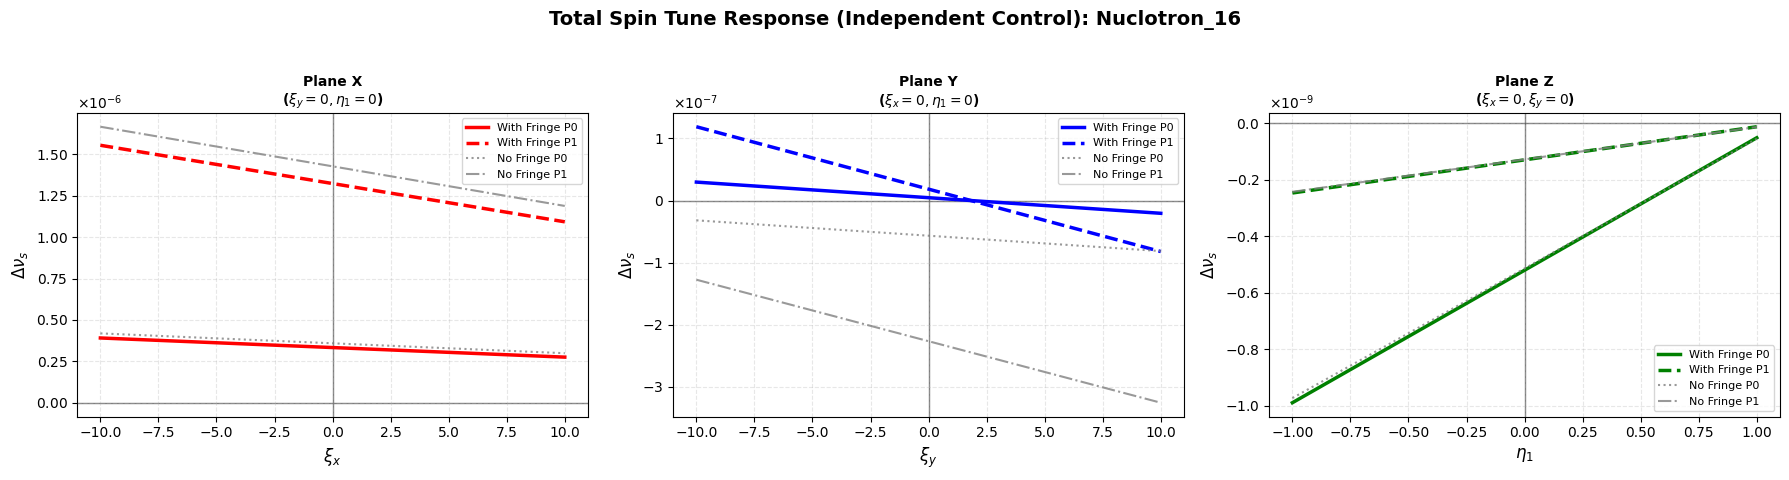

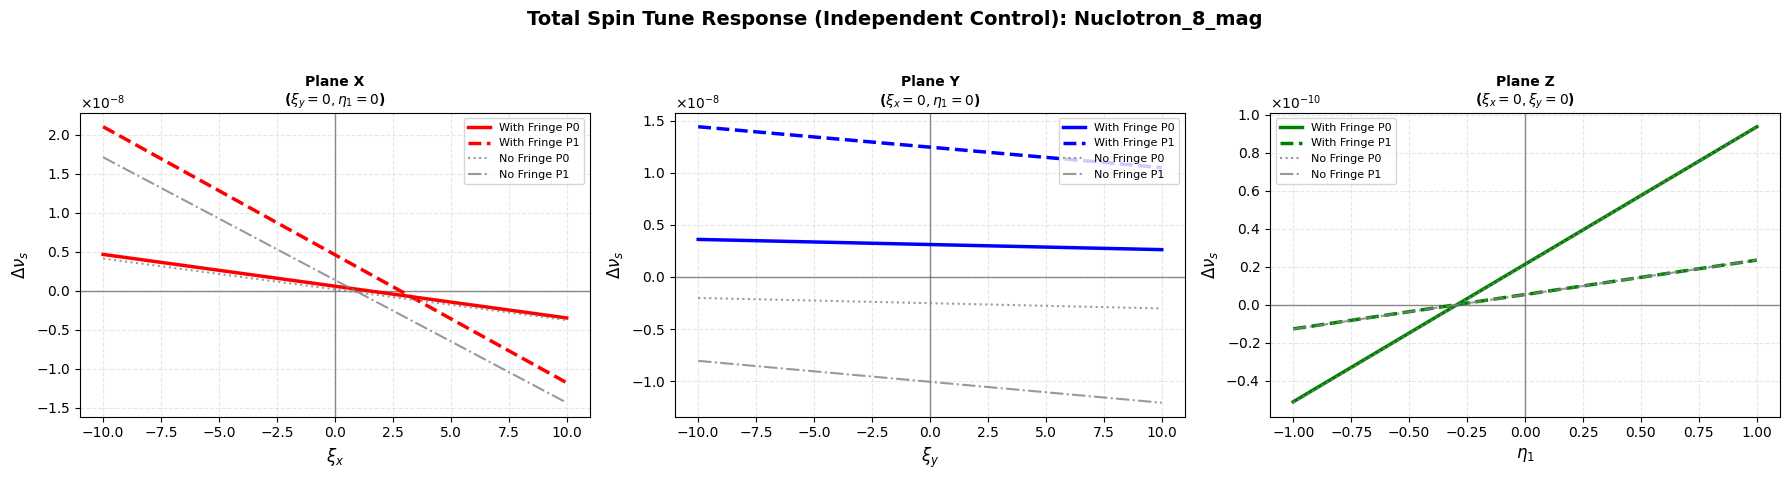

In [5]:
for lat in lattices:
    # Load data for the current lattice structure
    df_no_fr = get_data(lat, 'FR0') # Assumes get_data is defined
    df_with_fr = get_data(lat, 'FR3')
    if df_no_fr is None or df_with_fr is None: continue

    # --- Model Construction ---
    # Build independent R_spin and R_int models for every mode/particle combination
    lattice_models = {
        'NoFr_P0':   get_dual_model(df_no_fr, suffix=''),   
        'NoFr_P1':   get_dual_model(df_no_fr, suffix='_1'),
        'WithFr_P0': get_dual_model(df_with_fr, suffix=''), 
        'WithFr_P1': get_dual_model(df_with_fr, suffix='_1')
    }

    # Initialize the summary figure (1x3 grid)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Total Spin Tune Response (Independent Control): {lat}', fontsize=14, fontweight='bold')

    for i in range(3):
        ax = axes[i]
        res = {state: [] for state in lattice_models.keys()}

        for val in ranges[i]:
            # Set target chromaticity for the active plane; others forced to 0
            target_chrom = np.zeros(3)
            target_chrom[i] = val
            
            # --- INDEPENDENT SEXTUPOLE CONTROL CALCULATION ---
            # We determine the specific currents required for each lattice state
            
            # 1. Currents for 'No Fringe' configuration
            m_no_fr = lattice_models['NoFr_P0']
            try:
                I_no_fr = np.linalg.solve(m_no_fr['R_int'], target_chrom - m_no_fr['int_nat'])
            except np.linalg.LinAlgError:
                I_no_fr, _, _, _ = np.linalg.lstsq(m_no_fr['R_int'], target_chrom - m_no_fr['int_nat'], rcond=None)
            
            # 2. Currents for 'With Fringe' configuration
            m_with_fr = lattice_models['WithFr_P0']
            try:
                I_with_fr = np.linalg.solve(m_with_fr['R_int'], target_chrom - m_with_fr['int_nat'])
            except np.linalg.LinAlgError:
                I_with_fr, _, _, _ = np.linalg.lstsq(m_with_fr['R_int'], target_chrom - m_with_fr['int_nat'], rcond=None)

            # --- CALCULATE SPIN RESPONSE ---
            for state, model in lattice_models.items():
                # Assign the correct current vector based on the configuration
                current_I = I_no_fr if 'NoFr' in state else I_with_fr
                
                # nu_s = R_spin * I + spin_nat
                spin_tune = np.dot(model['R_spin'][i], current_I) + model['spin_nat'][i]
                res[state].append(spin_tune)

        # --- VISUALIZATION ---
        # Plot Fringe Fields (Main Focus)
        ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        
        # Plot Ideal Field (Reference)
        ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.8, label='No Fringe P0')
        ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.8, label='No Fringe P1')

        # Formatting: Zero axes, labels, and scientific notation
        ax.axhline(0, color='black', lw=1.0, alpha=0.5, zorder=0)
        ax.axvline(0, color='black', lw=1.0, alpha=0.5, zorder=0)
        ax.set_xlabel(labels[i], fontsize=12)
        ax.set_ylabel(r'$\Delta \nu_s$', fontsize=12)
        ax.set_title(f'Plane {plane_names[i].upper()}\n({constraints[i]})', fontweight='bold', fontsize=10)
        
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True); fmt.set_powerlimits((-2, 2))
        ax.yaxis.set_major_formatter(fmt)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, loc='best')

        # --- EXPORT INDIVIDUAL PLOTS ---
        # Generate stand-alone PNGs for presentation slides
        t_fig, t_ax = plt.subplots(figsize=(6, 5))
        t_ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        t_ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        t_ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.6, label='No Fringe P0')
        t_ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.6, label='No Fringe P1')
        
        t_ax.axhline(0, color='black', lw=1.0, alpha=0.5)
        t_ax.axvline(0, color='black', lw=1.0, alpha=0.5)
        t_ax.set_xlabel(labels[i]); t_ax.set_ylabel(r'$\Delta \nu_s$')
        t_ax.set_title(f"{lat} | {plane_names[i].upper()}-Plane | {constraints[i]}", fontsize=11)
        
        t_ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        t_ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        t_ax.grid(True, alpha=0.3); t_ax.legend(fontsize=9, loc='best')

        save_path = os.path.join(root_path, lat, f"{lat}_compare_dual_control_{plane_names[i]}.png")
        t_fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(t_fig)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Pure Dynamic Response Analysis (Sensitivity Only)

This iteration isolates the **sensitivity** of the spin tune to control parameters by omitting all "Natural" (baseline) components. By mathematically forcing the model through the origin, we observe the pure change in gradients (slopes) caused by fringe fields and orbital deviations.

### 1. Removing the Intercepts (The "Natural" Components)
In this mathematical mode, we strictly set the natural vectors to zero to analyze the system's Jacobian response in isolation:
*   $\Delta \vec{\nu}_{s, nat} = [0, 0, 0]^T$ (Ignoring inherent spin precession)
*   $\vec{\xi}_{nat} = [0, 0, 0]^T$ (Ignoring natural lattice chromaticity)

### 2. Modified Response Equations
The general linear model is reduced to a **Homogeneous System**. This allows us to compare how the governing equations change when we strip away the static offsets:


| Component | Total Model (Natural + Dynamic) | Pure Dynamic Model (Slopes Only) |
| :--- | :--- | :--- |
| **Currents ($\vec{I}$)** | $\vec{I} = \mathbf{R}_{int}^{-1} \cdot (\vec{\xi}_{target} - \color{red}{\vec{\xi}_{nat}})$ | $\vec{I}_{pure} = \mathbf{R}_{int}^{-1} \cdot \vec{\xi}_{target}$ |
| **Spin Tune ($\vec{\nu}_{s}$)** | $\vec{\nu}_{s} = \mathbf{R}_{spin} \cdot \vec{I} + \color{red}{\vec{\nu}_{s, nat}}$ | $\vec{\nu}_{s, pure} = \mathbf{R}_{spin} \cdot \vec{I}_{pure}$ |


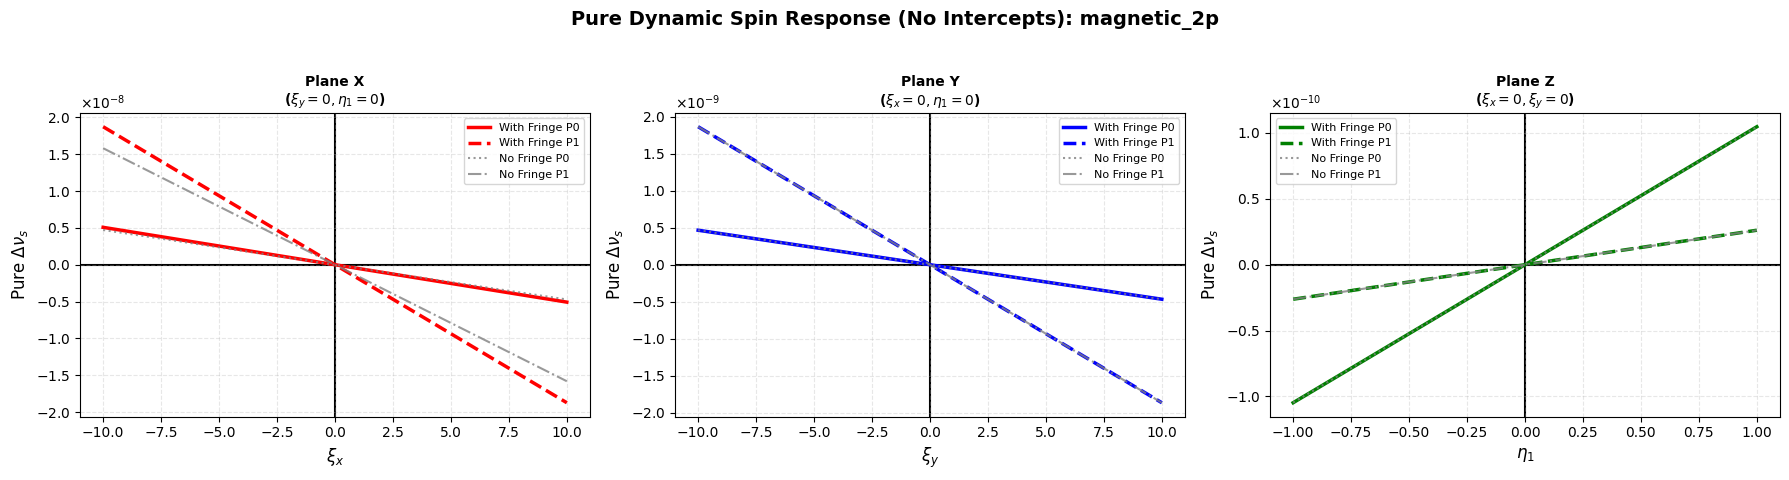

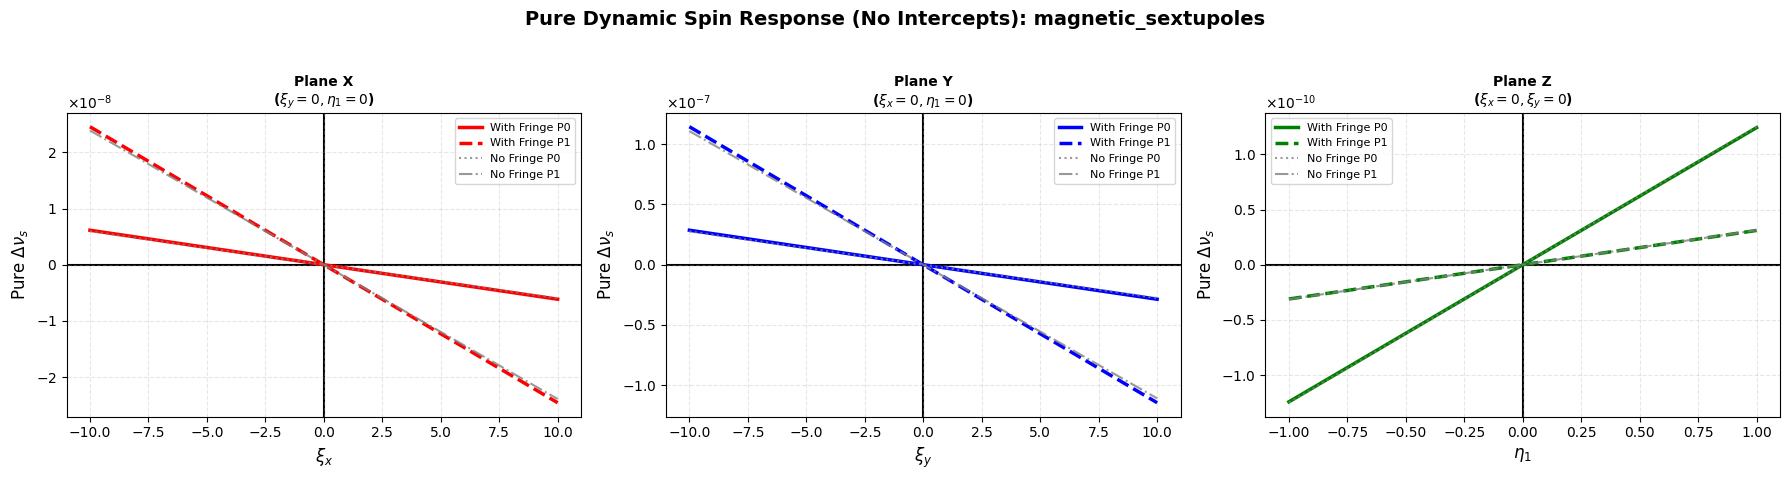

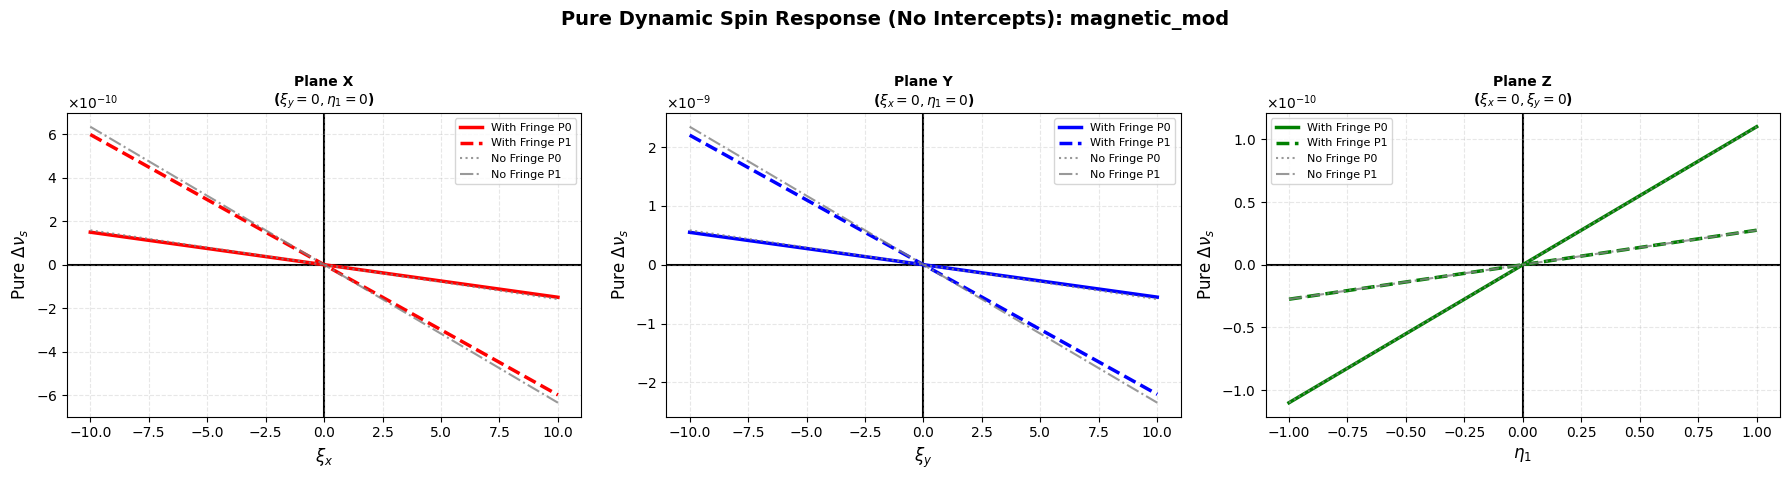

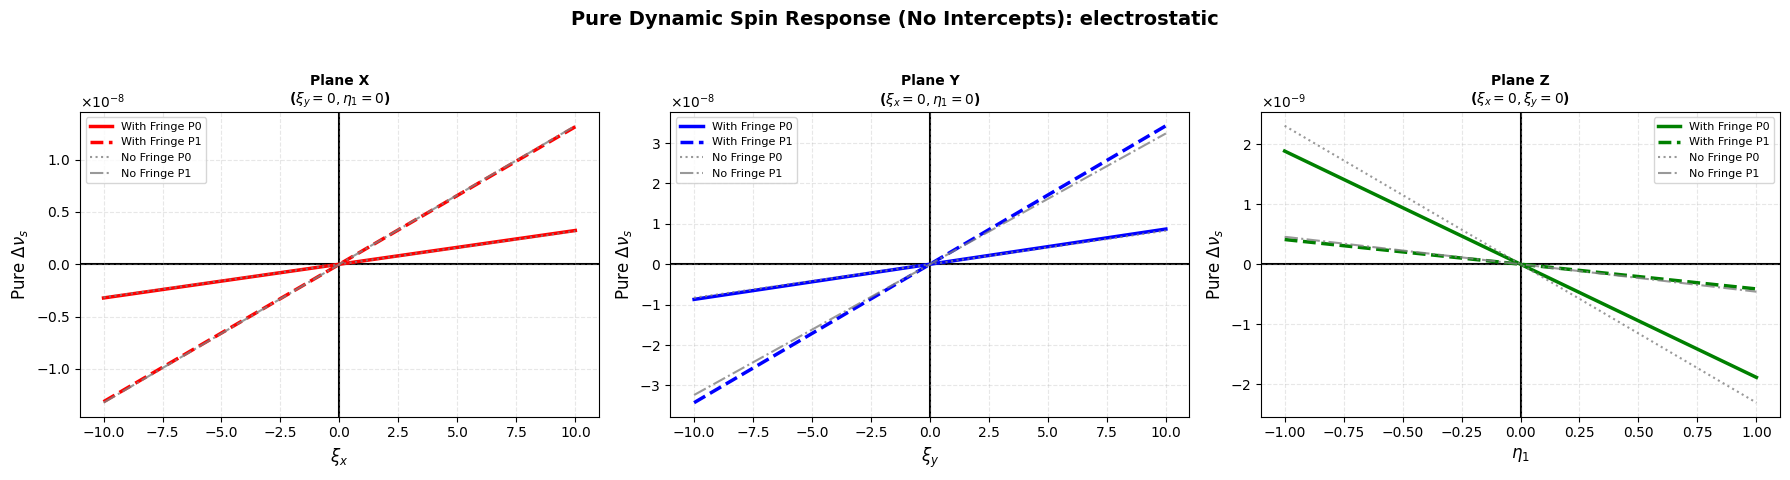

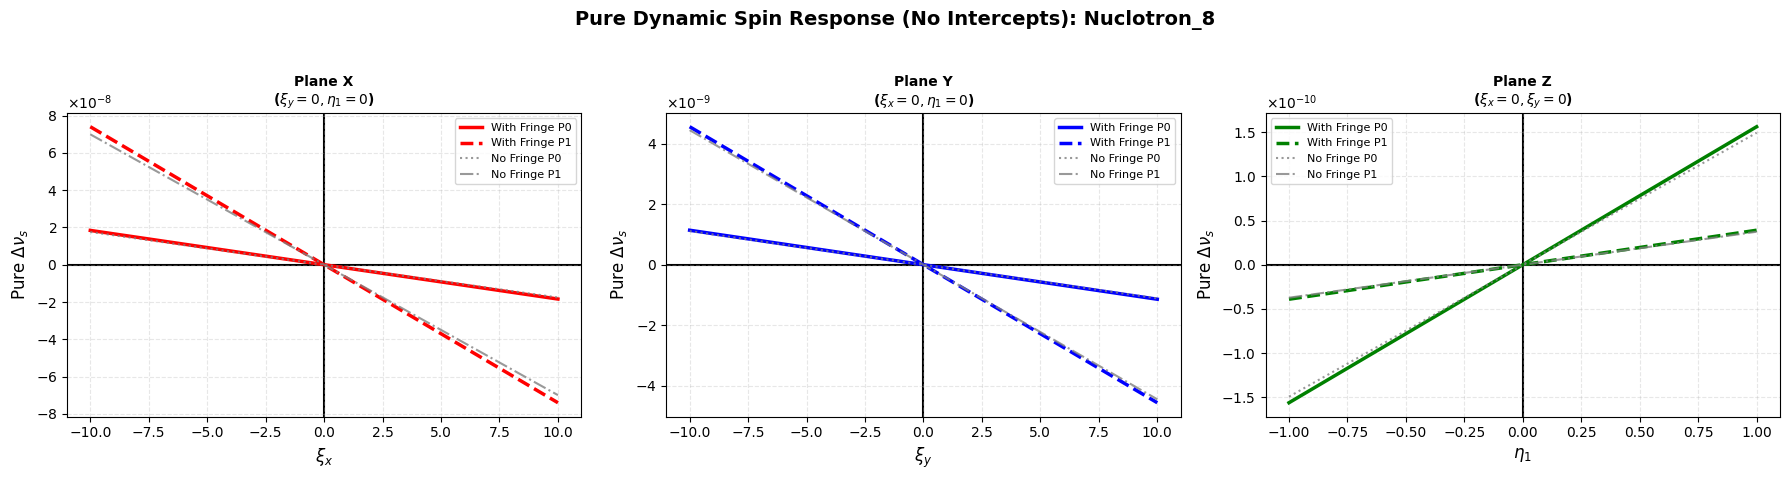

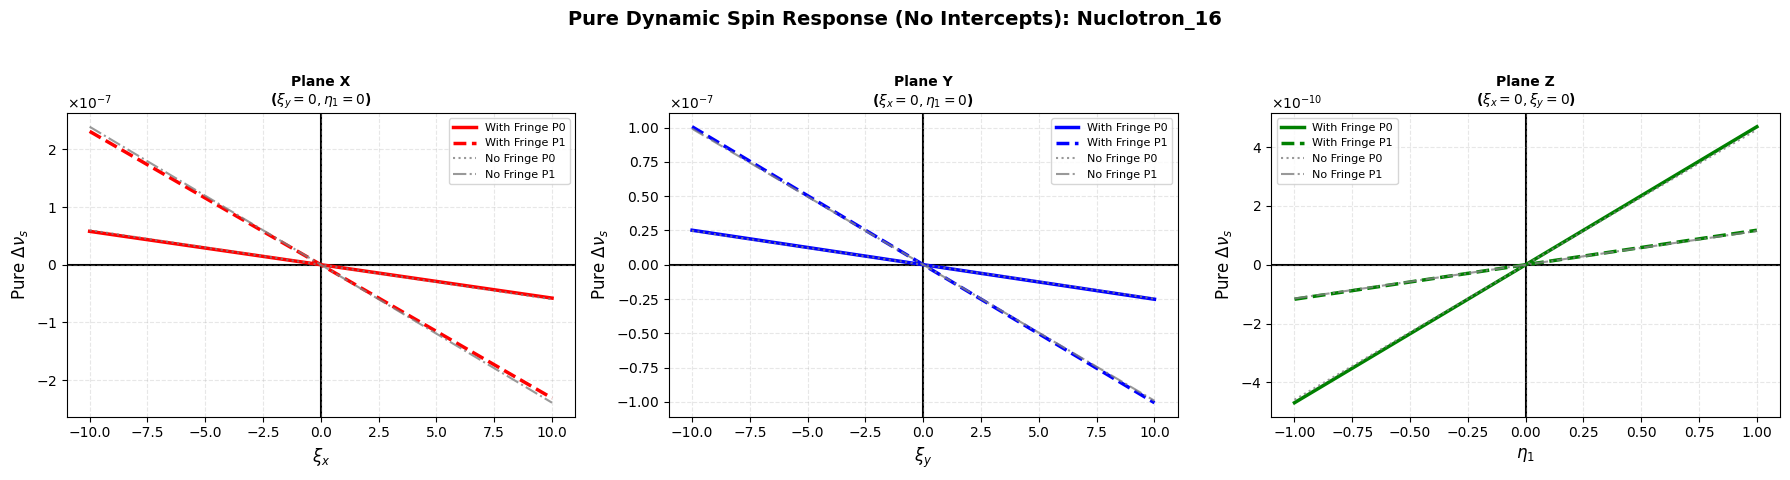

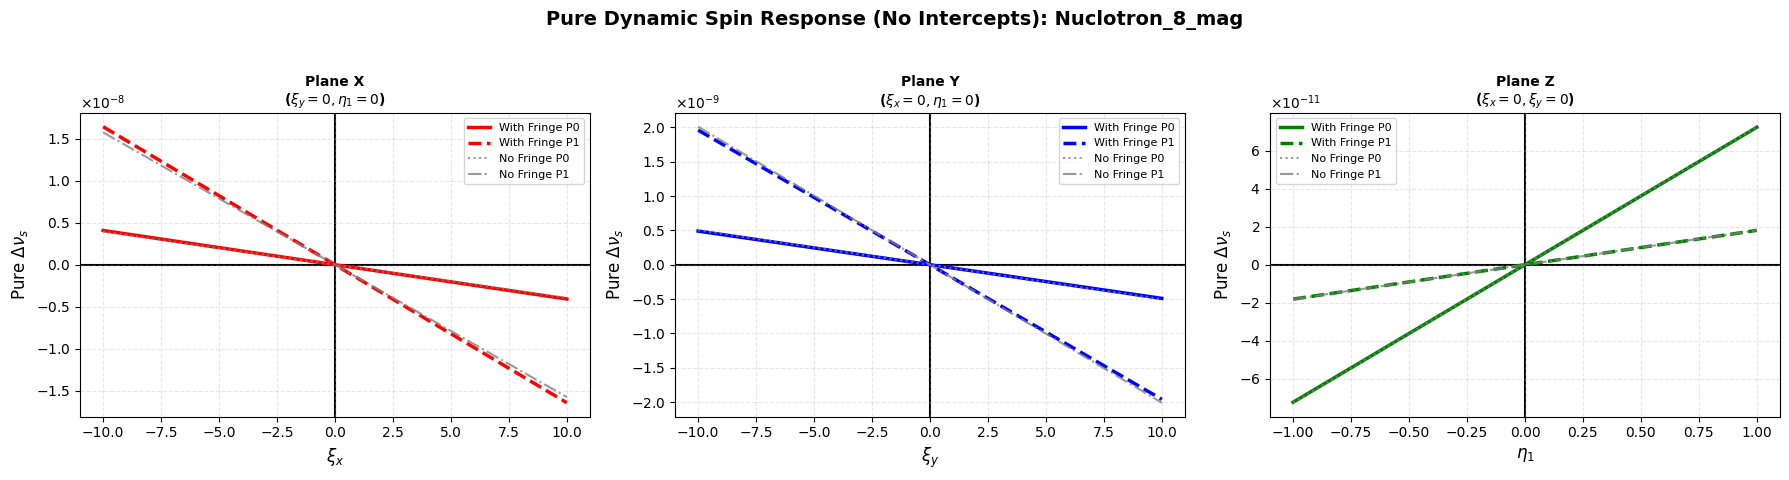

In [6]:
for lat in lattices:
    # Load data for the current lattice structure
    df_no_fr = get_data(lat, 'FR0') 
    df_with_fr = get_data(lat, 'FR3')
    if df_no_fr is None or df_with_fr is None: continue

    # --- Model Construction ---
    lattice_models = {
        'NoFr_P0':   get_dual_model(df_no_fr, suffix=''),   
        'NoFr_P1':   get_dual_model(df_no_fr, suffix='_1'),
        'WithFr_P0': get_dual_model(df_with_fr, suffix=''), 
        'WithFr_P1': get_dual_model(df_with_fr, suffix='_1')
    }

    # Initialize the summary figure (1x3 grid)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Pure Dynamic Spin Response (No Intercepts): {lat}', fontsize=14, fontweight='bold')

    for i in range(3):
        ax = axes[i]
        res = {state: [] for state in lattice_models.keys()}

        for val in ranges[i]:
            # Set target chromaticity for the active plane; others forced to 0
            target_chrom = np.zeros(3)
            target_chrom[i] = val
            
            # --- PURE CURRENT CALCULATION (int_nat ignored) ---
            # Finding currents required to change chromaticity from a zero base
            
            # 1. Currents for 'No Fringe' configuration
            m_no_fr = lattice_models['NoFr_P0']
            try:
                I_no_fr = np.linalg.solve(m_no_fr['R_int'], target_chrom)
            except np.linalg.LinAlgError:
                I_no_fr, _, _, _ = np.linalg.lstsq(m_no_fr['R_int'], target_chrom, rcond=None)
            
            # 2. Currents for 'With Fringe' configuration
            m_with_fr = lattice_models['WithFr_P0']
            try:
                I_with_fr = np.linalg.solve(m_with_fr['R_int'], target_chrom)
            except np.linalg.LinAlgError:
                I_with_fr, _, _, _ = np.linalg.lstsq(m_with_fr['R_int'], target_chrom, rcond=None)

            # --- PURE SPIN RESPONSE CALCULATION (spin_nat ignored) ---
            for state, model in lattice_models.items():
                # Assign the correct current vector based on the configuration
                current_I = I_no_fr if 'NoFr' in state else I_with_fr
                
                # nu_s_pure = R_spin * I (Linear slope only)
                spin_tune_pure = np.dot(model['R_spin'][i], current_I)
                res[state].append(spin_tune_pure)

        # --- VISUALIZATION ---
        ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.8, label='No Fringe P0')
        ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.8, label='No Fringe P1')

        # Formatting: Zero axes (essential for pure response), labels, and scientific notation
        ax.axhline(0, color='black', lw=1.5, zorder=0)
        ax.axvline(0, color='black', lw=1.5, zorder=0)
        ax.set_xlabel(labels[i], fontsize=12)
        ax.set_ylabel(r'Pure $\Delta \nu_s$', fontsize=12)
        ax.set_title(f'Plane {plane_names[i].upper()}\n({constraints[i]})', fontweight='bold', fontsize=10)
        
        fmt = ScalarFormatter(useMathText=True)
        fmt.set_scientific(True); fmt.set_powerlimits((-2, 2))
        ax.yaxis.set_major_formatter(fmt)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, loc='best')

        # --- EXPORT INDIVIDUAL PLOTS ---
        t_fig, t_ax = plt.subplots(figsize=(6, 5))
        t_ax.plot(ranges[i], res['WithFr_P0'], color=colors[i], ls='-', lw=2.5, label='With Fringe P0')
        t_ax.plot(ranges[i], res['WithFr_P1'], color=colors[i], ls='--', lw=2.5, label='With Fringe P1')
        t_ax.plot(ranges[i], res['NoFr_P0'], color='gray', ls=':', alpha=0.6, label='No Fringe P0')
        t_ax.plot(ranges[i], res['NoFr_P1'], color='gray', ls='-.', alpha=0.6, label='No Fringe P1')
        
        t_ax.axhline(0, color='black', lw=1.5)
        t_ax.axvline(0, color='black', lw=1.5)
        t_ax.set_xlabel(labels[i]); t_ax.set_ylabel(r'Pure $\Delta \nu_s$')
        t_ax.set_title(f"{lat} | {plane_names[i].upper()}-Plane | Sensitivity", fontsize=11)
        
        t_ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        t_ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        t_ax.grid(True, alpha=0.3); t_ax.legend(fontsize=9, loc='best')

        save_path = os.path.join(root_path, lat, f"{lat}_pure_dynamic_{plane_names[i]}.png")
        t_fig.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(t_fig)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Mathematical Verification of Model Integrity

This section performs a self-consistency check to ensure that the extracted Jacobians and the resulting transfer functions accurately represent the underlying lattice physics.

### 1. Coupled Linear System
The verification assumes that the machine observables are linear transformations of the sextupole currents $\vec{I}$:

$$
\begin{cases} 
\vec{\xi} = \mathbf{R}_{int} \cdot \vec{I} + \vec{\xi}_{nat} & \text{(Chromaticity Control)} \\
\Delta\vec{\nu}_s = \mathbf{R}_{spin} \cdot \vec{I} + \Delta\vec{\nu}_{s, nat} & \text{(Spin Response)} 
\end{cases}
$$

### 2. End-to-End Linkage Strategy ($\vec{\xi} \to \Delta\vec{\nu}_s$)
To validate the **chromaticity-to-spin relationship**, we perform an "End-to-End" reconstruction. We take the raw chromaticity data ($\vec{\xi}_{actual}$) from the COSY-INFINITY dataset and pass it through the combined model to predict the spin tune deviation:

$$\Delta\vec{\nu}_{s, predicted} = \mathbf{R}_{spin} \cdot \left[ \mathbf{R}_{int}^{-1} \cdot (\vec{\xi}_{actual} - \vec{\xi}_{nat}) \right] + \Delta\vec{\nu}_{s, nat}$$

This test confirms that the mapping between the two physical observables is consistent and that the matrix inversion used in the control logic is numerically stable.

### 3. Statistical Validation ($R^2$)
The adequacy of the linear fit and the linkage is quantified by the **Coefficient of Determination ($R^2$)**:

$$ R^2 = 1 - \frac{\sum (\Delta\nu_{s, actual} - \Delta\nu_{s, predicted})^2}{\sum (\Delta\nu_{s, actual} - \overline{\Delta\nu}_{s, actual})^2} $$

*   **Sensitivity Correlation**: A high $R^2$ demonstrates that the spin tune deviation is driven by the same magnetic non-linearities that determine the chromaticity.
*   **Linearity Confirmation**: It proves that higher-order effects (e.g., $I^2$) are negligible, justifying the use of Jacobian-based sensitivity operators ($\mathbf{S} = \mathbf{R}_{spin} \cdot \mathbf{R}_{int}^{-1}$).

**Success Criterion**: All points falling on the $45^\circ$ diagonal in the *Measured vs. Predicted* plots with $R^2 \approx 1.0$ prove that the model is a physically adequate representation of the spin-chromaticity coupling.

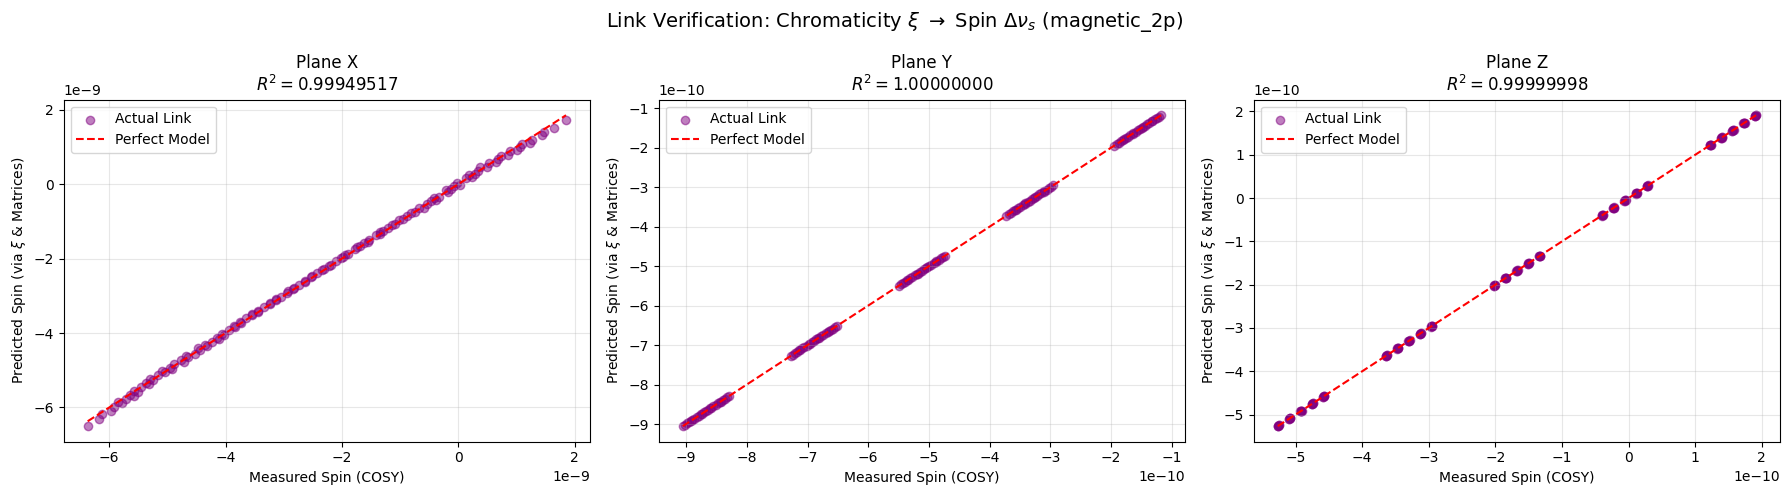

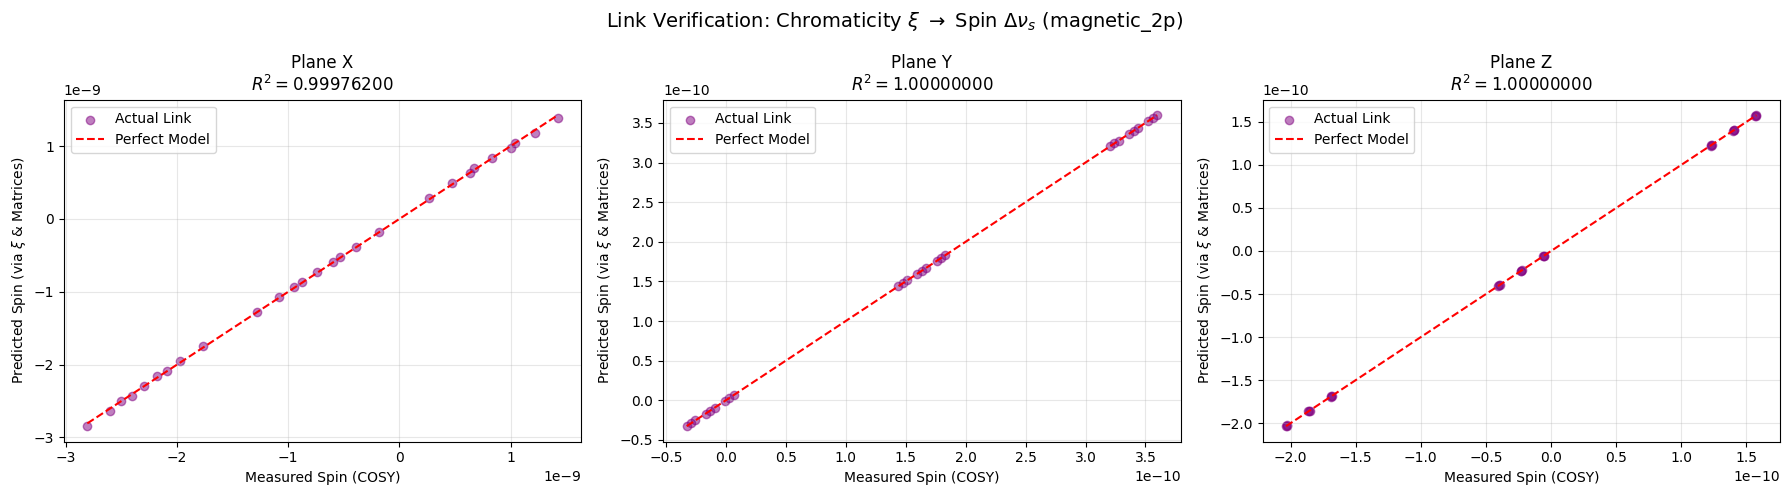

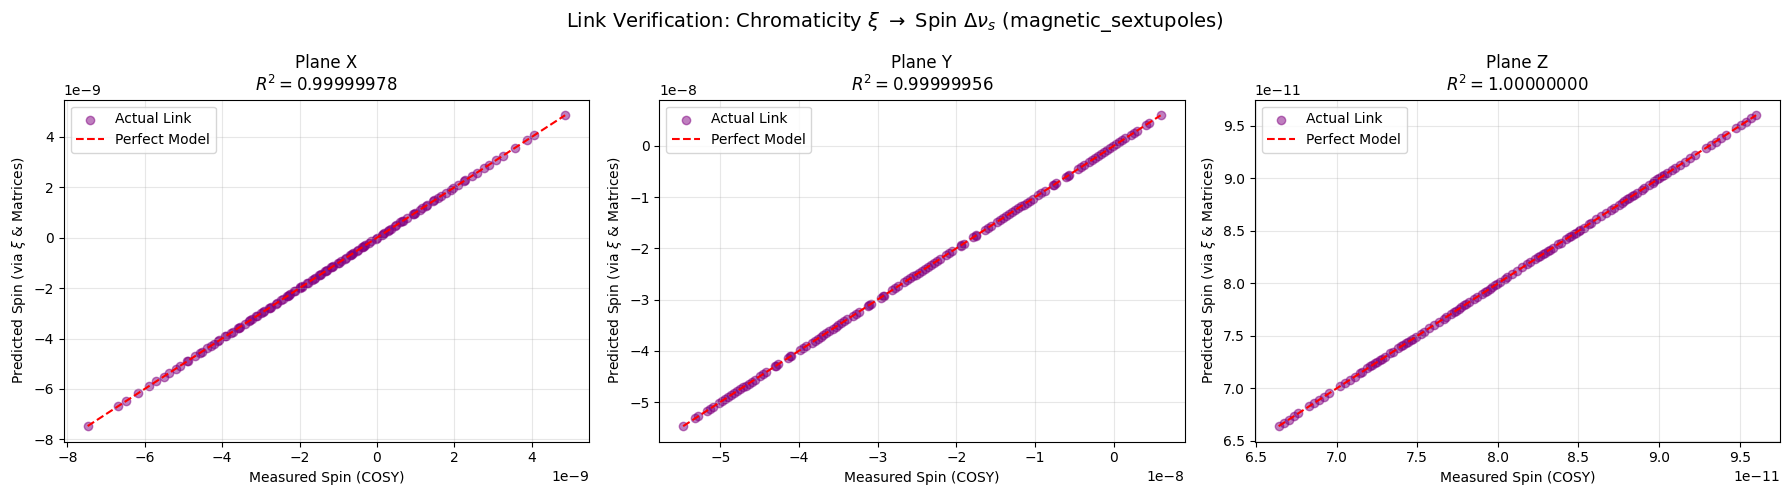

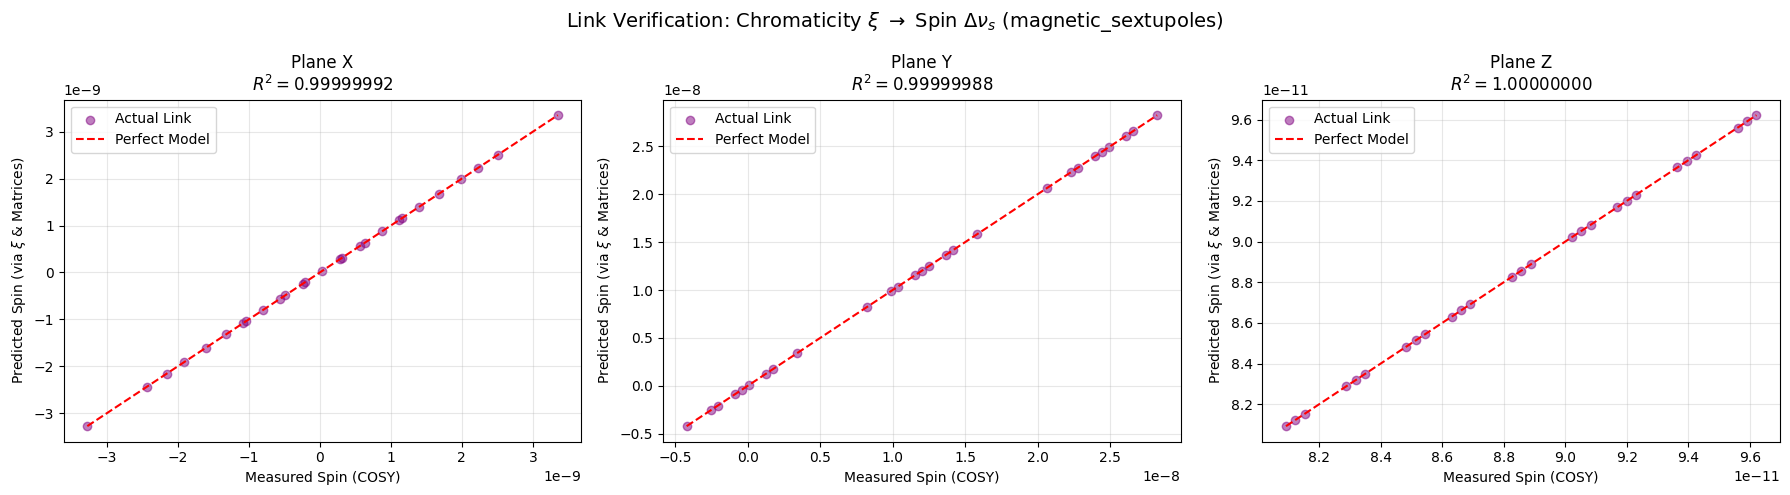

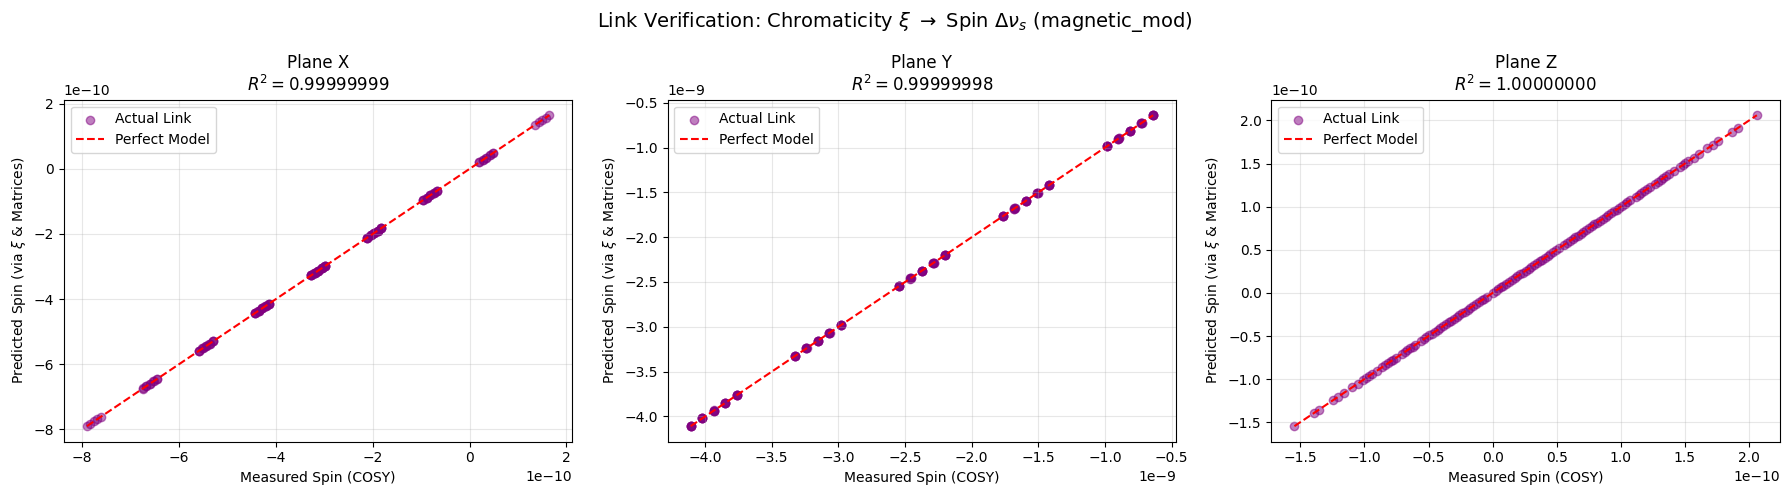

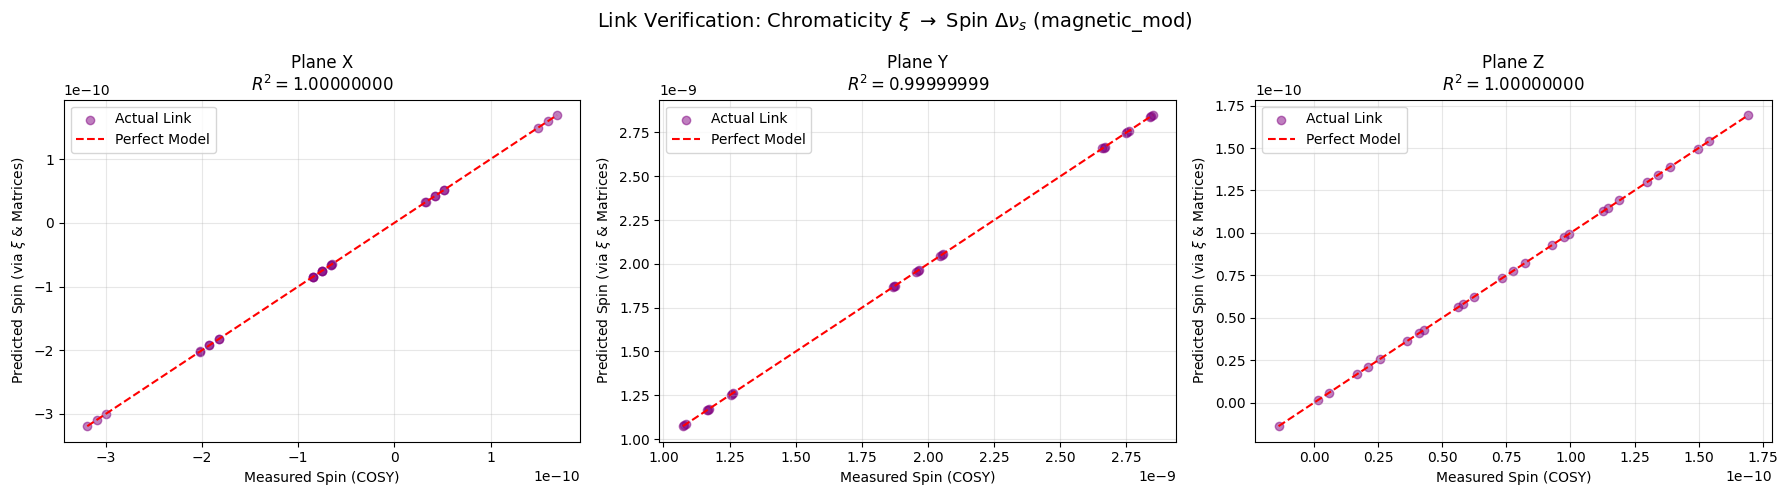

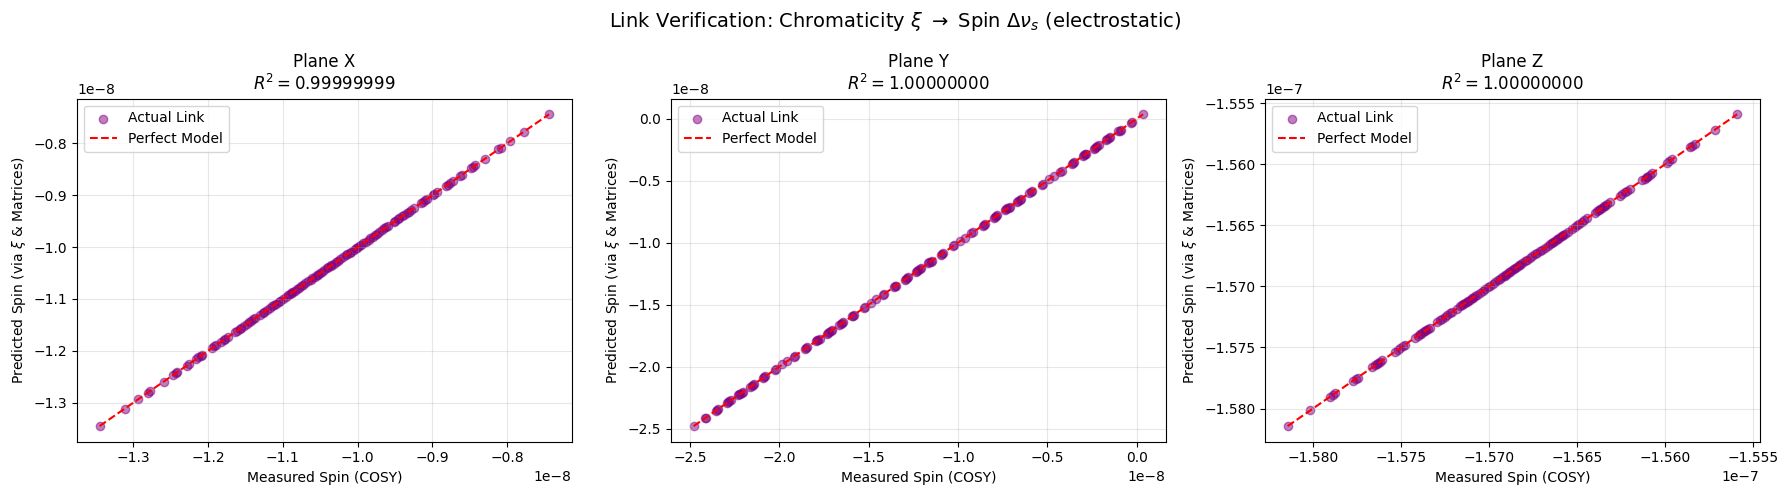

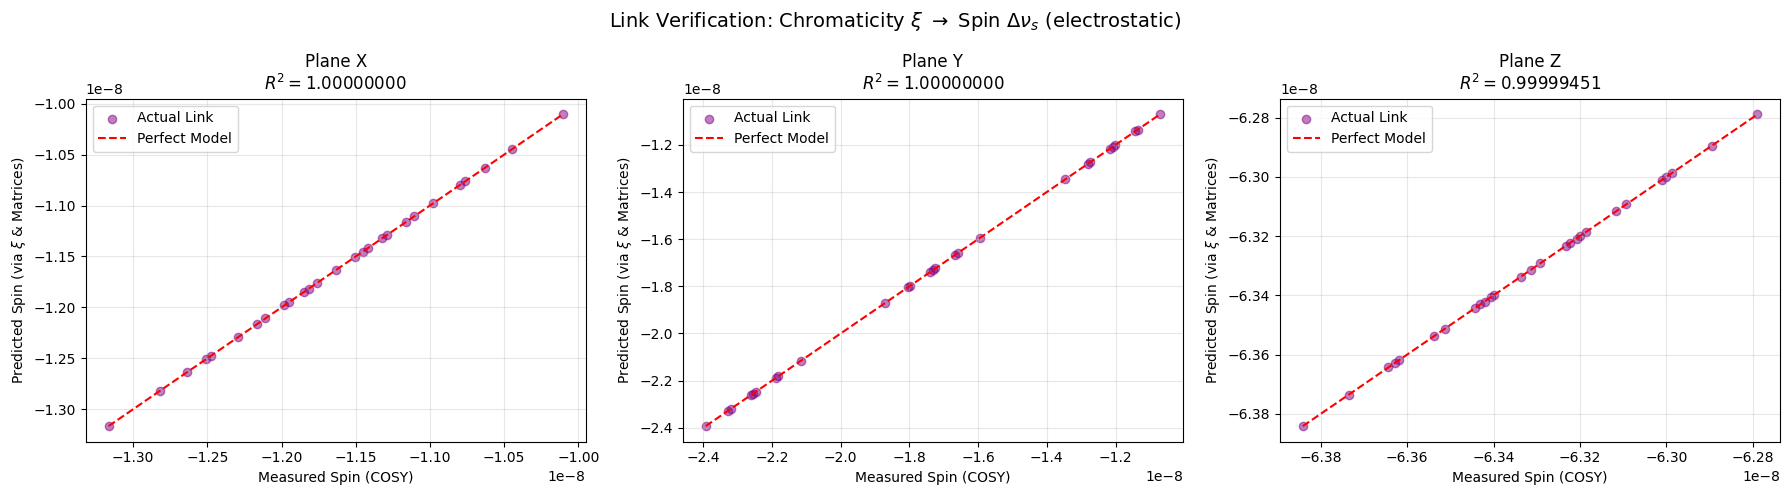

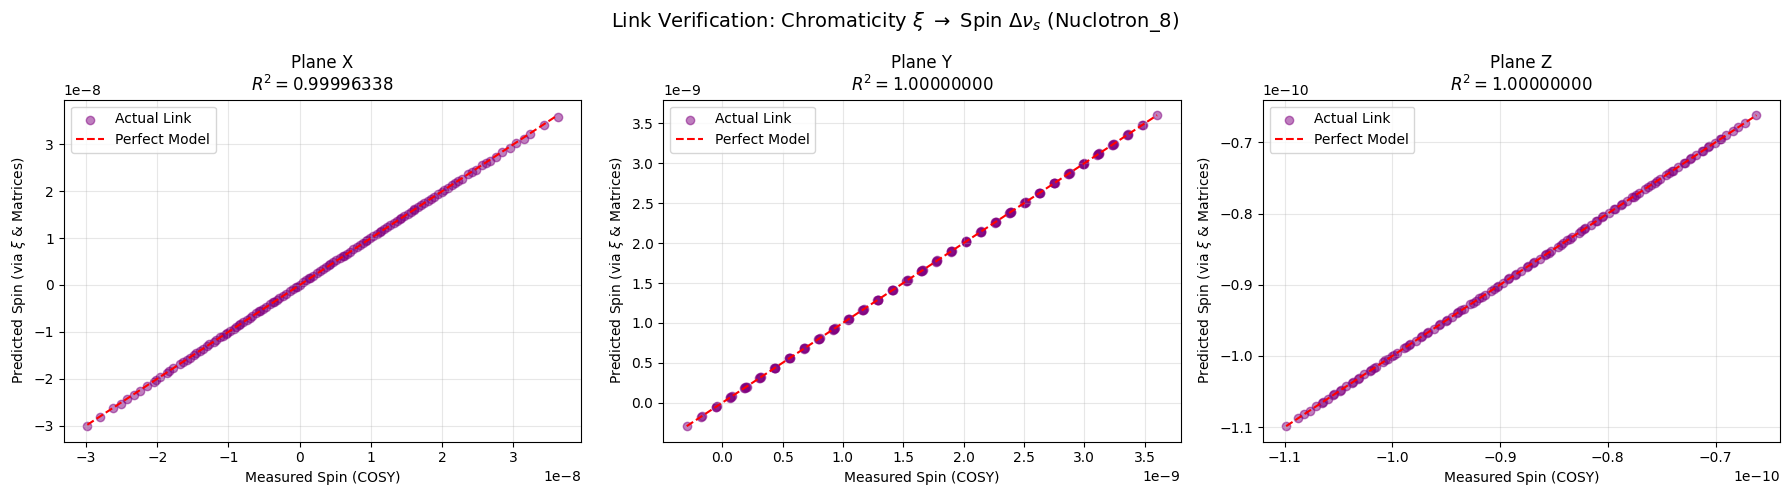

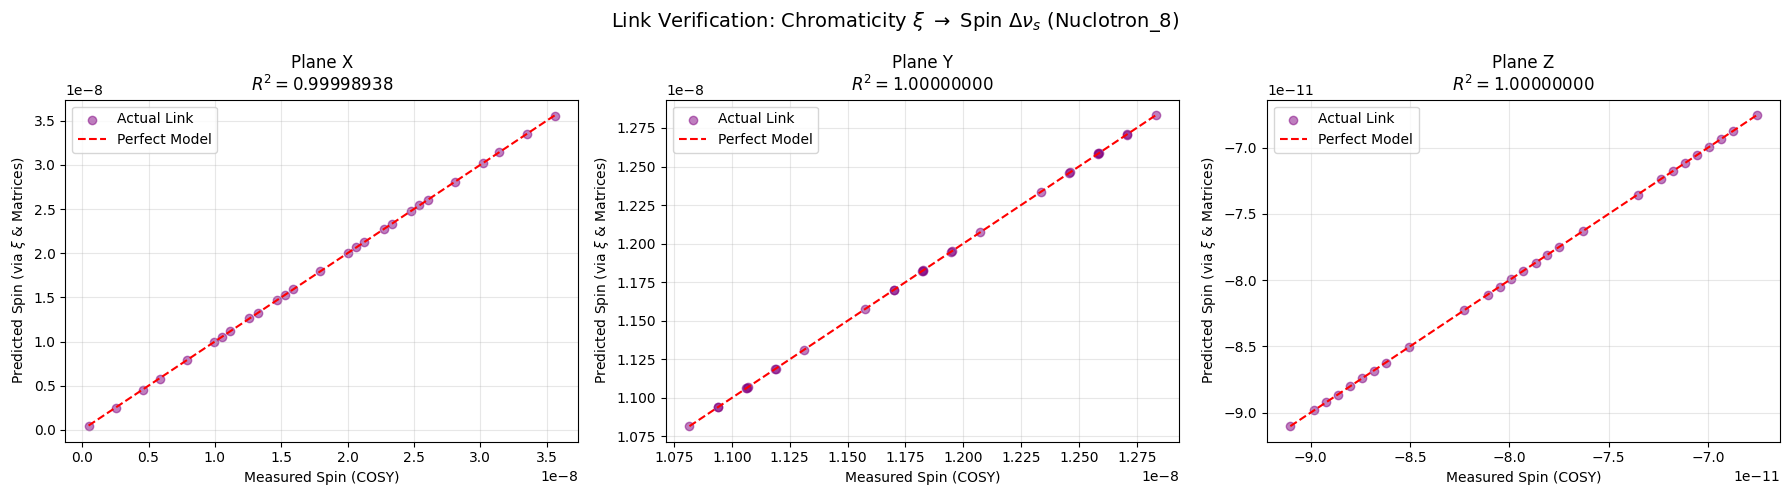

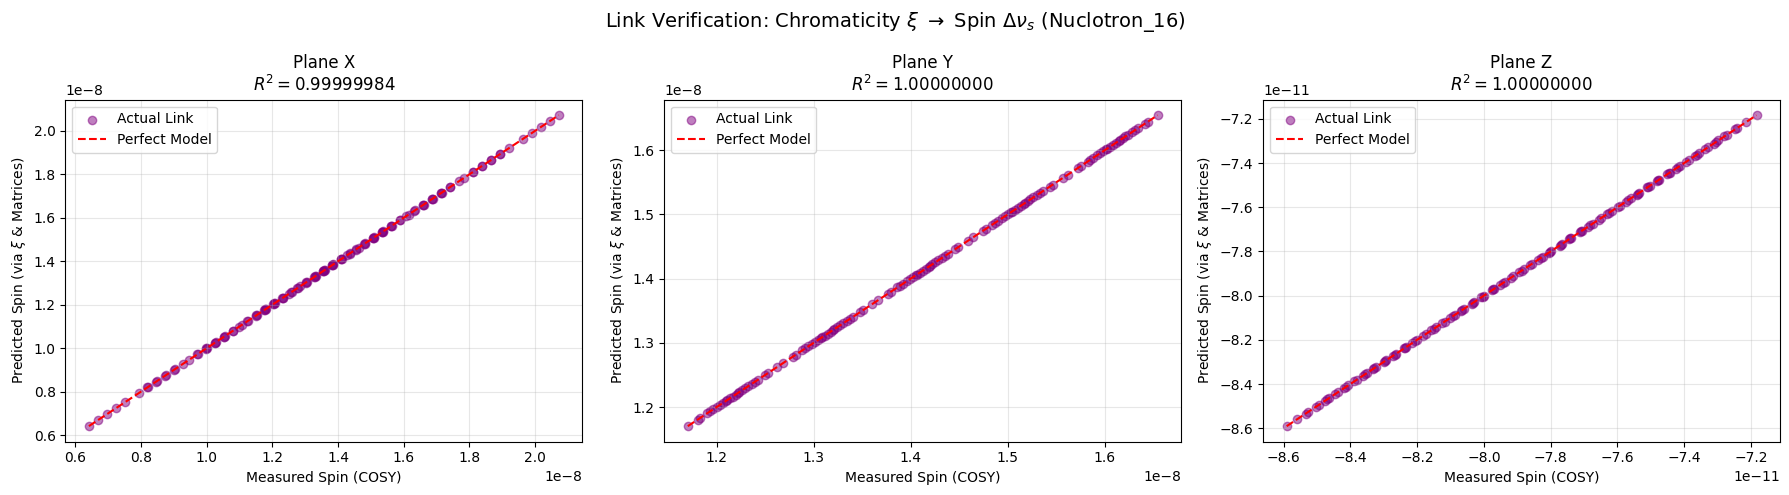

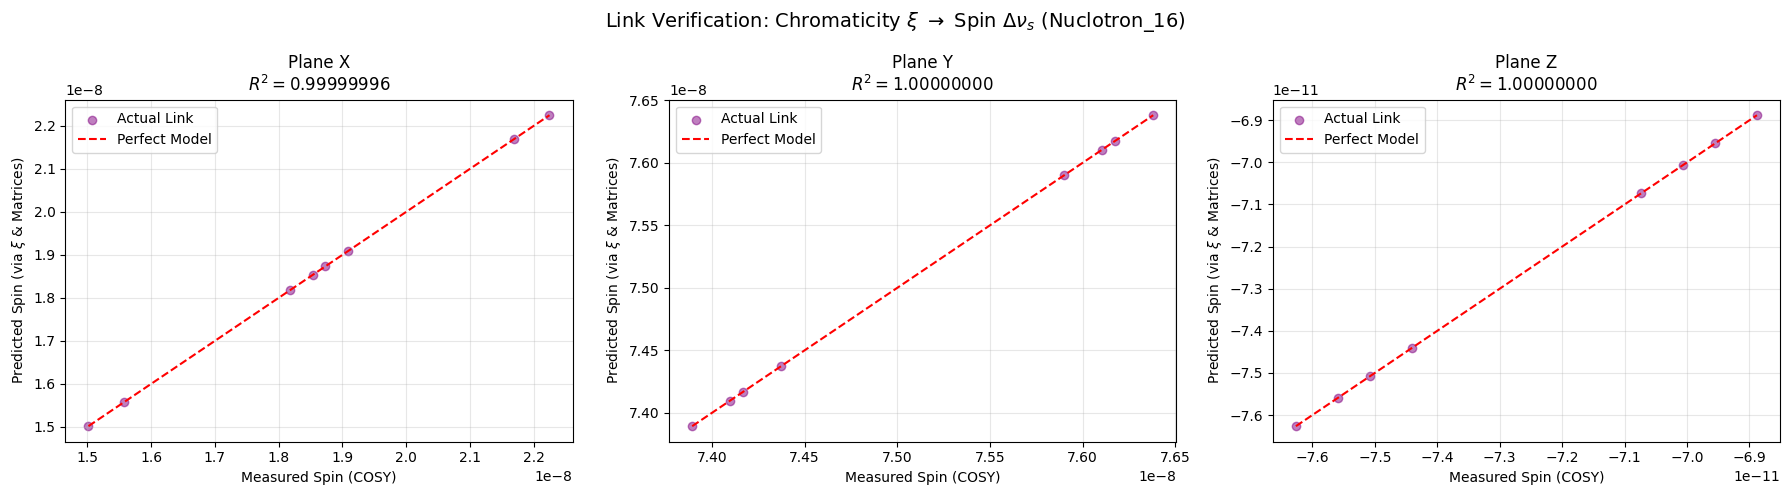

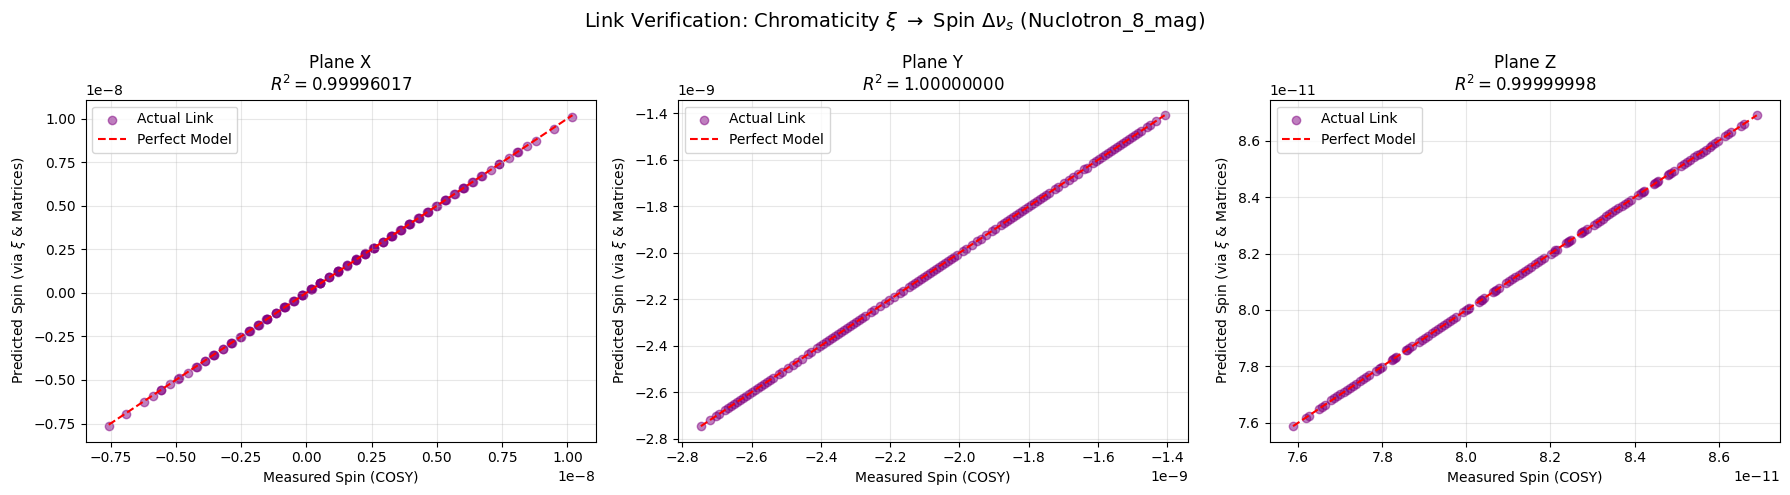

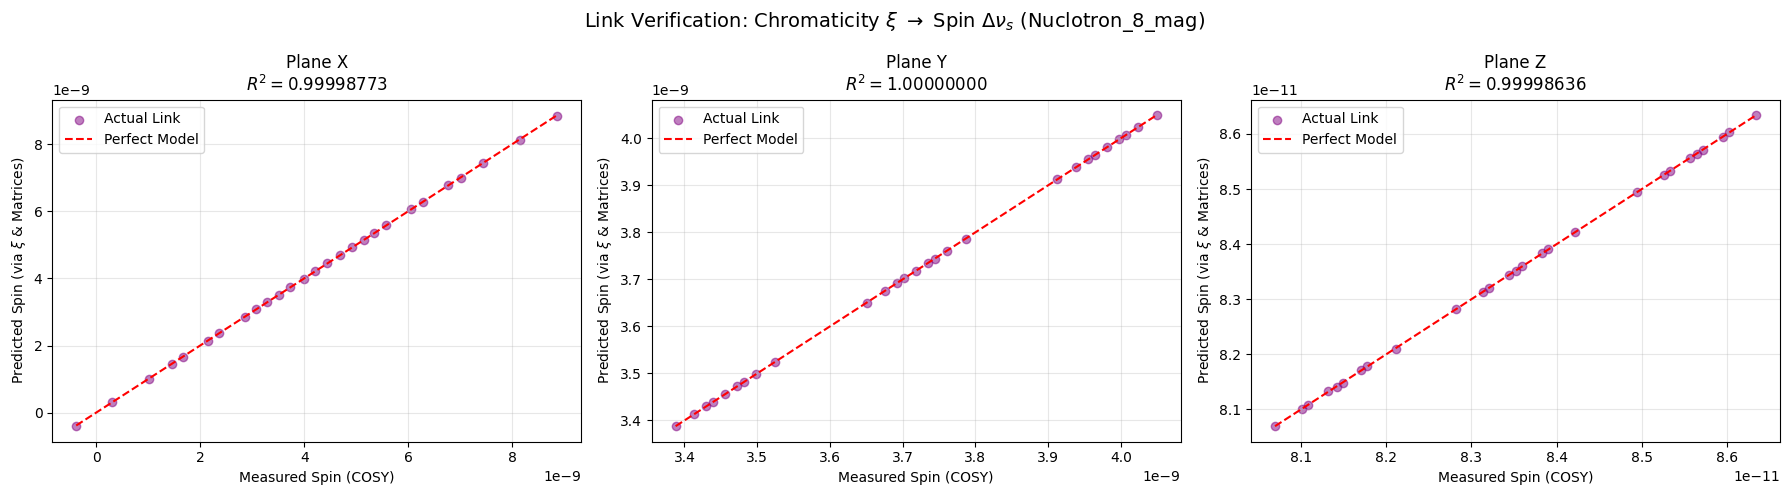

In [7]:
def verify_chrom_to_spin_link(lat, mode):
    df = get_data(lat, mode)
    if df is None: return

    # 1. Получаем модели (A, B, C, D)
    m = get_dual_model(df, suffix='') # Для Particle 0

    # 2. Исходные данные из файла
    xi_actual = df[['chrom_x', 'chrom_y', 'eta_1']].values
    spin_actual = df[['spin_x', 'spin_y', 'spin_z']].values

    # 3. ПРОВЕРКА СВЯЗИ: Chromaticity -> Currents -> Spin
    spin_predicted = []
    
    for i in range(len(xi_actual)):
        # Находим токи, соответствующие ДАННОЙ хроматичности из файла
        # I = R_int^-1 * (xi_actual - xi_nat)
        try:
            I_calc = np.linalg.solve(m['R_int'], xi_actual[i] - m['int_nat'])
        except:
            I_calc,_,_,_ = np.linalg.lstsq(m['R_int'], xi_actual[i] - m['int_nat'], rcond=None)
        
        # Считаем спин, который ДОЛЖЕН БЫТЬ при этой хроматичности по нашей модели
        # spin = R_spin * I + spin_nat
        s_pred = np.dot(m['R_spin'], I_calc) + m['spin_nat']
        spin_predicted.append(s_pred)

    spin_predicted = np.array(spin_predicted)

    # 4. ОТРИСОВКА КОРРЕЛЯЦИИ
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Link Verification: Chromaticity $\\xi$ $\\to$ Spin $\\Delta \\nu_s$ ({lat})', fontsize=14)

    for i in range(3):
        ax = axes[i]
        true_s = spin_actual[:, i]
        pred_s = spin_predicted[:, i]
        
        r2 = 1 - (np.sum((true_s - pred_s)**2) / np.sum((true_s - np.mean(true_s))**2))
        
        ax.scatter(true_s, pred_s, color='purple', alpha=0.5, label='Actual Link')
        
        lims = [true_s.min(), true_s.max()]
        ax.plot(lims, lims, 'r--', label='Perfect Model')
        
        ax.set_title(f'Plane {["X","Y","Z"][i]}\n$R^2 = {r2:.8f}$')
        ax.set_xlabel('Measured Spin (COSY)')
        ax.set_ylabel('Predicted Spin (via $\\xi$ & Matrices)')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Запуск проверки для всех решеток
for lat in lattices:
   verify_chrom_to_spin_link(lat, 'FR0')
   verify_chrom_to_spin_link(lat, 'FR3')